MSE: 9.20
R²: 0.87


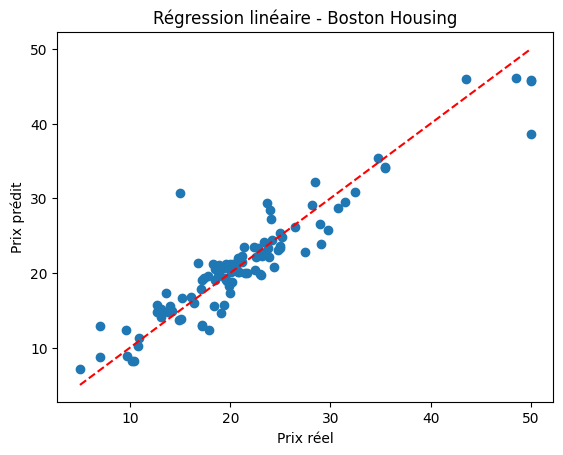

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

# Charger le dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Séparation des variables
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Régression linéaire
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

# Visualisation
plt.scatter(y_test, y_pred)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Régression linéaire - Boston Housing")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Charger les données
url = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"
df = pd.read_csv(url)

print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [9]:
print(y)

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64


In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

print(df.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


Train Accuracy: 1.00
Test Accuracy: 0.87


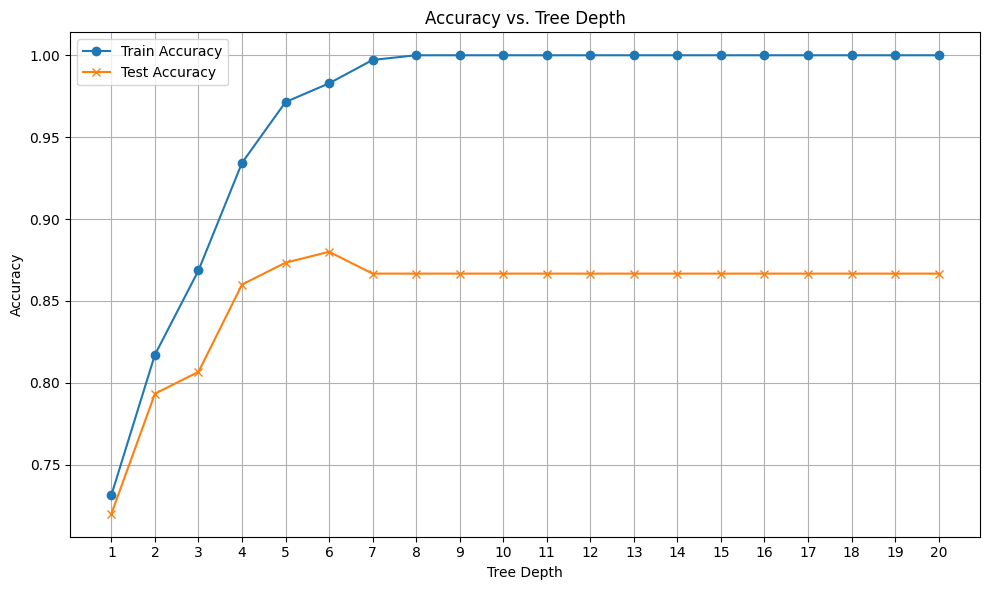

In [11]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=42,
    shuffle=True
)

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Plot accuracy evolution as tree depth increases
train_accuracies = []
test_accuracies = []
depths = range(1, 21)  # Tree depths from 1 to 20

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='x')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Tree Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.tight_layout()
plt.show()


Train Accuracy: 0.92
Test Accuracy: 0.81


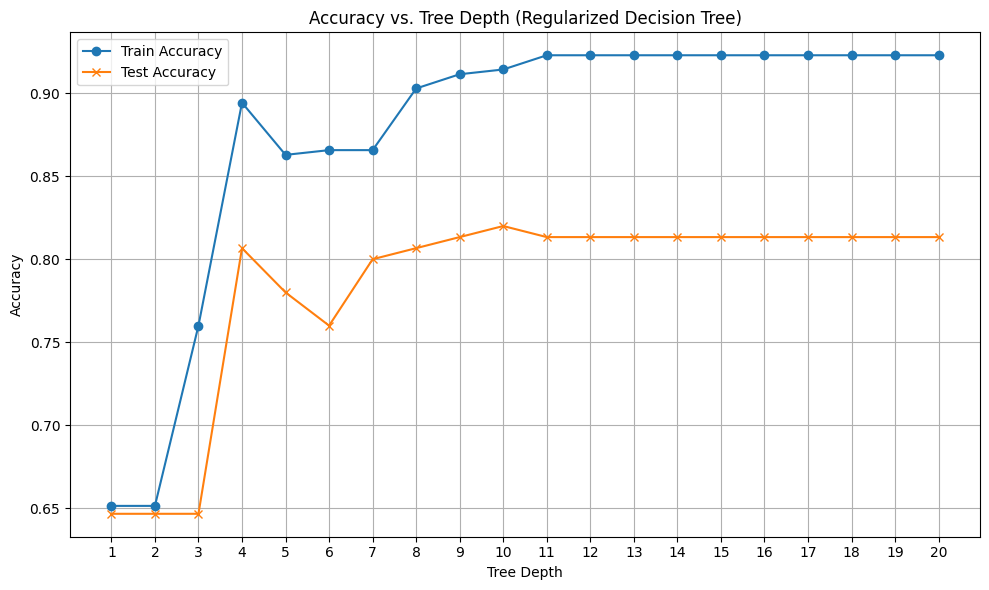

In [12]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    random_state=42,
    shuffle=True
)

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Try a range of depths to find balanced performance
train_accuracies = []
test_accuracies = []
depths = range(1, 21)

for depth in depths:
    clf = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_split=10,     # minimum number of samples required to split
        min_samples_leaf=5,       # minimum number of samples per leaf
        max_features='sqrt',      # limit the number of features considered
        random_state=42
    )
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))


train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

# 4. Plotting accuracy vs depth
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='x')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Tree Depth (Regularized Decision Tree)')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.tight_layout()
plt.show()


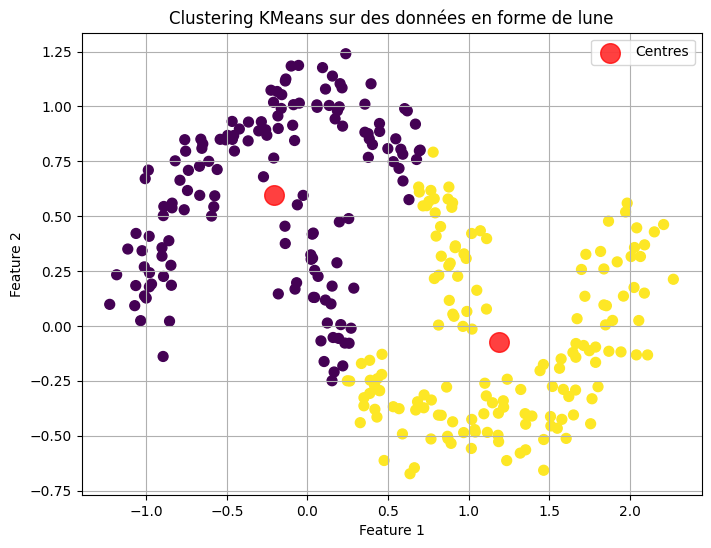

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# 1. Génération des données en forme de lune
X, y_true = make_moons(n_samples=300, noise=0.1, random_state=42)

# 2. Application de KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# 3. Affichage des clusters trouvés par KMeans
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', s=200, alpha=0.75, label='Centres')
plt.title("Clustering KMeans sur des données en forme de lune")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


{np.int64(0), np.int64(1)}


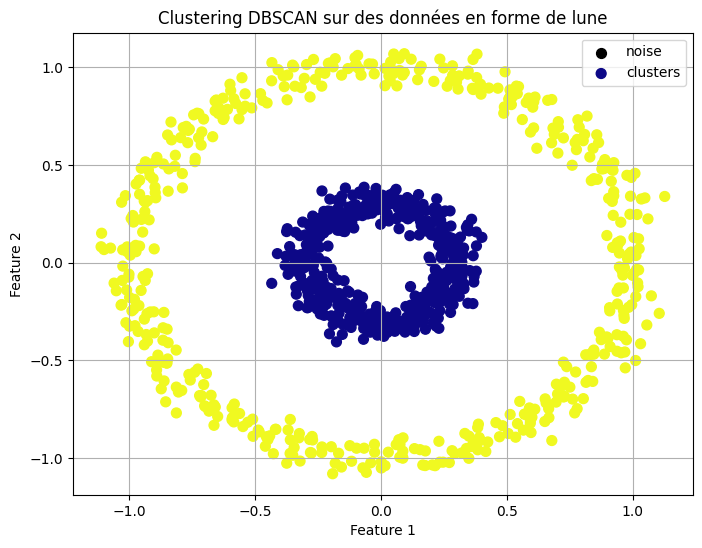

In [28]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, y_true = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)

dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

print(set(y_dbscan))  # Pour voir les labels détectés

plt.figure(figsize=(8, 6))
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1], c='black', s=50, label='noise')
plt.scatter(X[y_dbscan != -1, 0], X[y_dbscan != -1, 1], c=y_dbscan[y_dbscan != -1], cmap='plasma', s=50, label='clusters')
plt.title("Clustering DBSCAN sur des données en forme de lune")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()
plt.show()


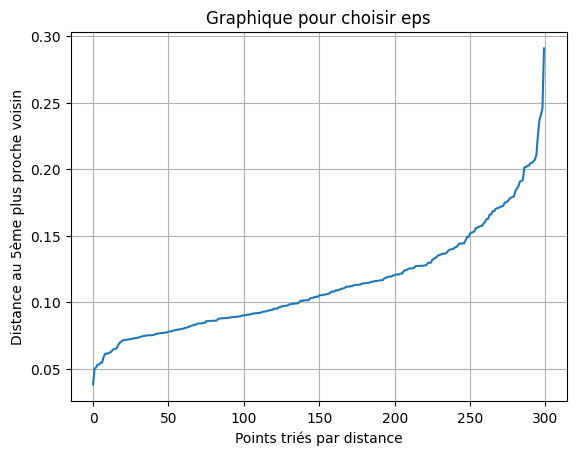

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, 4])  # distance au 5ème plus proche voisin
plt.plot(distances)
plt.ylabel("Distance au 5ème plus proche voisin")
plt.xlabel("Points triés par distance")
plt.title("Graphique pour choisir eps")
plt.grid(True)
plt.show()


In [18]:
for eps in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    for min_samples in [3, 4, 5, 6]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"eps={eps}, min_samples={min_samples} -> clusters: {n_clusters}")


eps=0.1, min_samples=3 -> clusters: 16
eps=0.1, min_samples=4 -> clusters: 17
eps=0.1, min_samples=5 -> clusters: 20
eps=0.1, min_samples=6 -> clusters: 15
eps=0.15, min_samples=3 -> clusters: 3
eps=0.15, min_samples=4 -> clusters: 2
eps=0.15, min_samples=5 -> clusters: 2
eps=0.15, min_samples=6 -> clusters: 3
eps=0.2, min_samples=3 -> clusters: 2
eps=0.2, min_samples=4 -> clusters: 2
eps=0.2, min_samples=5 -> clusters: 2
eps=0.2, min_samples=6 -> clusters: 2
eps=0.25, min_samples=3 -> clusters: 1
eps=0.25, min_samples=4 -> clusters: 1
eps=0.25, min_samples=5 -> clusters: 1
eps=0.25, min_samples=6 -> clusters: 1
eps=0.3, min_samples=3 -> clusters: 1
eps=0.3, min_samples=4 -> clusters: 1
eps=0.3, min_samples=5 -> clusters: 1
eps=0.3, min_samples=6 -> clusters: 1
eps=0.35, min_samples=3 -> clusters: 1
eps=0.35, min_samples=4 -> clusters: 1
eps=0.35, min_samples=5 -> clusters: 1
eps=0.35, min_samples=6 -> clusters: 1
eps=0.4, min_samples=3 -> clusters: 1
eps=0.4, min_samples=4 -> clusters

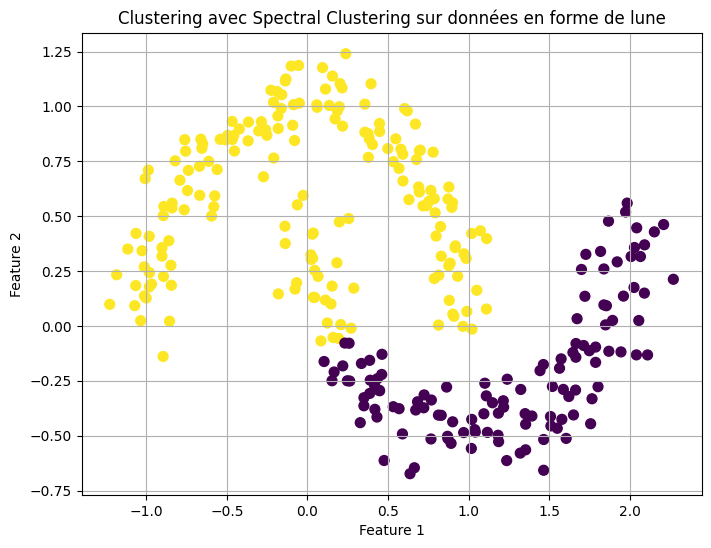

In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import SpectralClustering

# Génération des données en forme de lune
X, y_true = make_moons(n_samples=300, noise=0.1, random_state=42)

# Application de Spectral Clustering
sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=15, assign_labels='kmeans', random_state=42)
labels = sc.fit_predict(X)

# Affichage des clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Clustering avec Spectral Clustering sur données en forme de lune")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


{np.int64(0), np.int64(1)}


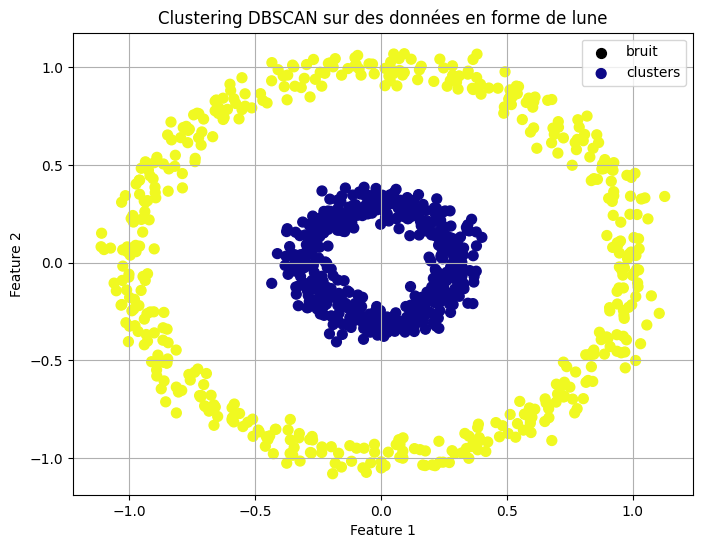

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, y_true = make_circles(n_samples=1000, factor=0.3, noise=0.05,
                          random_state=0)

dbscan = DBSCAN(eps=0.4, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

print(set(y_dbscan))  

plt.figure(figsize=(8, 6))
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1], 
            c='black', s=50, label='noise')
plt.scatter(X[y_dbscan != -1, 0], X[y_dbscan != -1, 1], 
            c=y_dbscan[y_dbscan != -1], cmap='plasma', s=50, 
            label='clusters')
plt.title("Clustering DBSCAN on circles data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()
plt.show()


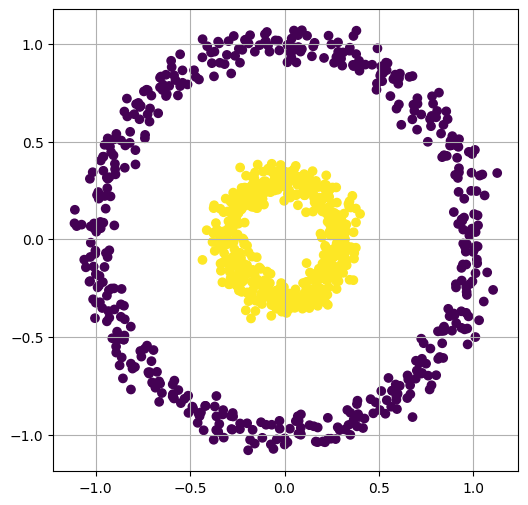

In [5]:
# make circles
from sklearn.datasets import make_circles
X_circle, y_circle = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle)
plt.grid()
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_circle, y_circle,
                                                     random_state=0)

clf = LogisticRegression(random_state = 0).fit(X_train,y_train)

print(f"Classification score r^2 on circle", 
      clf.score(X_test, y_test))

Classification score r^2 on circle 0.312


Text(0.5, 1.0, 'classification')

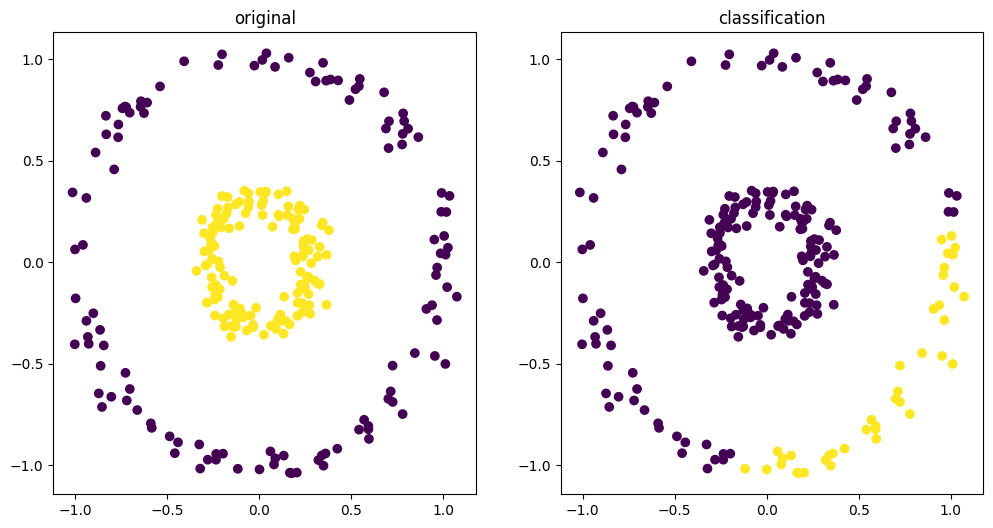

In [8]:
fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
ax.set_title('original')

# 
y_pred = clf.predict(X_test)
ax = fig.add_subplot(1, 2, 2)
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
ax.set_title('classification')